# 🛩️ BioGuard — AI-Powered Engine Health Monitoring
### Predictive Maintenance System using NASA CMAPSS Dataset

---
**Author:** Yash Dhollakhandi  
**Dataset:** NASA CMAPSS Turbofan Engine Degradation (FD001)  
**Objective:** Classify aircraft engine health as 🟢 SAFE | 🟡 WARNING | 🔴 CRITICAL using sensor time series data  
**Model:** XGBoost with Scikit-learn Pipeline  

---

## 1. 📦 Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

## 2. 📂 Load Dataset

The NASA CMAPSS FD001 dataset contains run-to-failure data from **100 turbofan engines** operating under a single condition (sea level).  
Each row represents one flight cycle of one engine, with readings from **21 sensors** and **3 operational settings**.  
The file has no header and contains 2 extra whitespace columns at the end which are handled below.

In [5]:
columns = ['engine_id', 'time_cycle',
           'setting_1', 'setting_2', 'setting_3',
           's1','s2','s3','s4','s5',
           's6','s7','s8','s9','s10',
           's11','s12','s13','s14','s15',
           's16','s17','s18','s19','s20','s21',
           'extra1', 'extra2']

df = pd.read_csv(r'C:\Users\yashd\Downloads\data\data1\data2\train_FD001.txt',
                  sep=' ', header=None, names=columns)

# Drop extra NaN columns
df = df.drop(['extra1', 'extra2'], axis=1)

print('Shape:', df.shape)
df.head()

Shape: (20631, 26)


,engine_id,time_cycle,setting_1,setting_2,setting_3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## 3. 🎯 RUL Calculation & Condition Labeling

**Remaining Useful Life (RUL)** = How many cycles are left before the engine fails.

```
RUL = max_cycle_of_engine - current_cycle
```

Based on RUL, we assign 3 health conditions:

| Condition | RUL | Meaning |
|---|---|---|
| 🟢 SAFE (0) | > 50 cycles | Engine is healthy |
| 🟡 WARNING (1) | 16–50 cycles | Schedule maintenance |
| 🔴 CRITICAL (2) | ≤ 15 cycles | Ground immediately |

In [7]:
# Calculate RUL
df['rul'] = df.groupby('engine_id')['time_cycle'].transform('max') - df['time_cycle']

# Assign condition labels
def label_condition(rul):
    if rul <= 15:
        return 2    # CRITICAL
    elif rul <= 50:
        return 1    # WARNING
    else:
        return 0    # SAFE

df['condition'] = df['rul'].apply(label_condition)

print('Condition Distribution:')
print(df['condition'].value_counts())
df.head()

Condition Distribution:
condition
0    15531
1     3500
2     1600
Name: count, dtype: int64


,engine_id,time_cycle,setting_1,setting_2,setting_3,s1,s2,s3,s4,s5,...,s14,s15,s16,s17,s18,s19,s20,s21,rul,condition
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191,0
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190,0
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189,0
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188,0
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187,0


## 4. 📊 Exploratory Data Analysis (EDA)

### 4.1 Condition Distribution

This plot shows how many readings fall under each health condition.  
The class imbalance (SAFE >> WARNING > CRITICAL) reflects real-world engine behavior — engines spend most of their life in a healthy state.

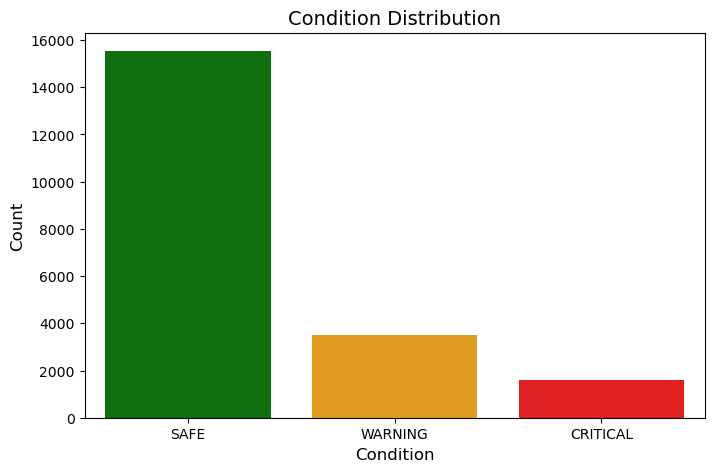

In [9]:
condition_map = {0: 'SAFE', 1: 'WARNING', 2: 'CRITICAL'}
df['condition_label'] = df['condition'].map(condition_map)

plt.figure(figsize=(8, 5))
sns.countplot(x='condition_label', data=df,
              order=['SAFE', 'WARNING', 'CRITICAL'],
              hue='condition_label',
              palette={'SAFE': 'green', 'WARNING': 'orange', 'CRITICAL': 'red'},
              legend=False)
plt.title('Condition Distribution', fontsize=14)
plt.xlabel('Condition', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

### 4.2 Sensor Distribution — SAFE vs WARNING vs CRITICAL

This plot shows how sensor values shift as the engine approaches failure.  
**Key Insight:** If the green (SAFE) and red (CRITICAL) distributions are separated, that sensor is useful for prediction.  
If they overlap completely, the sensor carries no predictive signal.

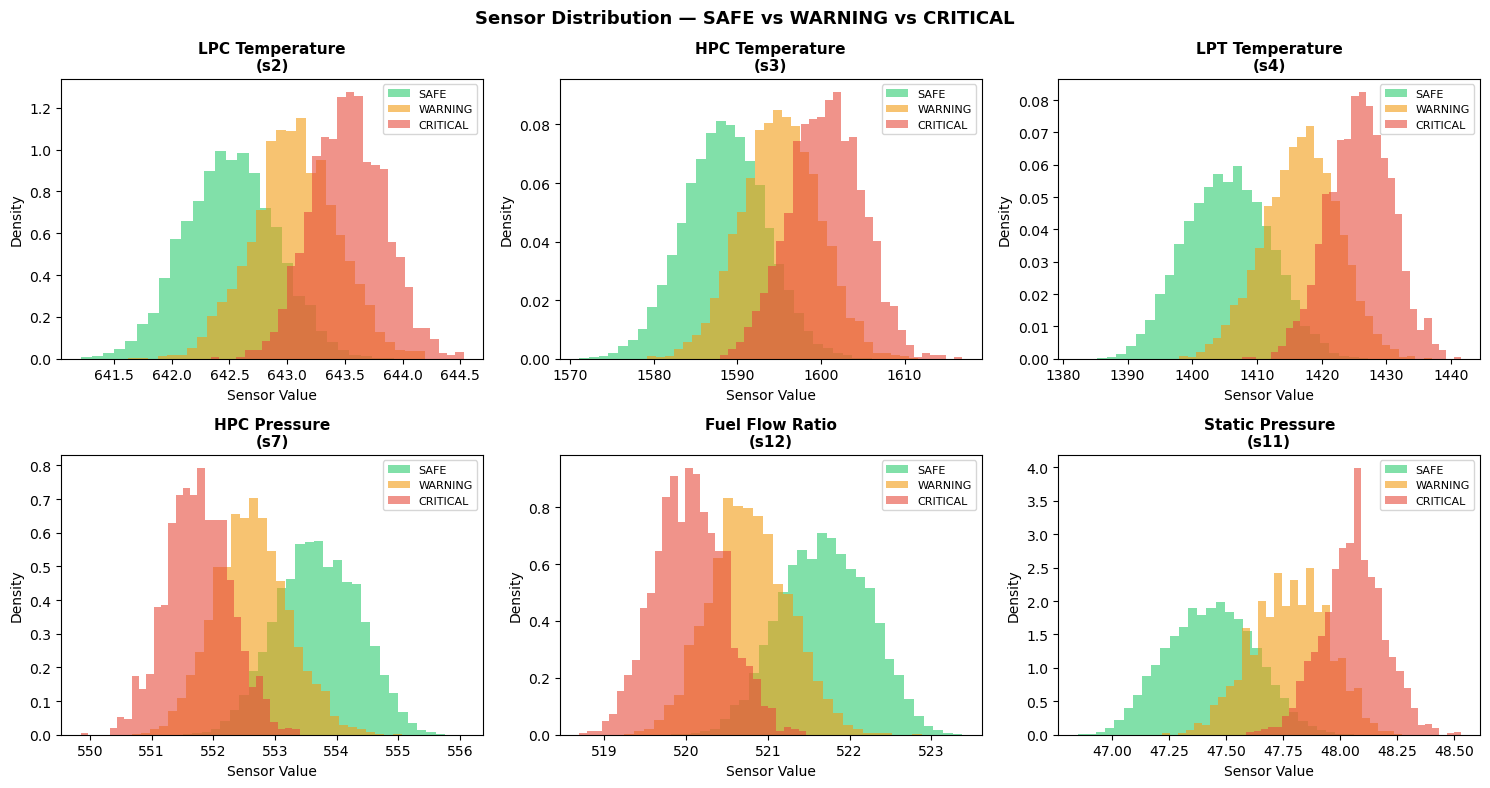

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

sensors_plot = {
    's2': 'LPC Temperature', 's3': 'HPC Temperature',
    's4': 'LPT Temperature', 's7': 'HPC Pressure',
    's12': 'Fuel Flow Ratio', 's11': 'Static Pressure'
}
colors = {'SAFE': '#2ecc71', 'WARNING': '#f39c12', 'CRITICAL': '#e74c3c'}

for i, (sensor, name) in enumerate(sensors_plot.items()):
    ax = axes[i//3][i%3]
    for condition, color in colors.items():
        data = df[df['condition_label'] == condition][sensor]
        ax.hist(data, bins=30, alpha=0.6, color=color, label=condition, density=True)
    ax.set_title(f'{name}\n({sensor})', fontsize=11, fontweight='bold')
    ax.set_xlabel('Sensor Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle('Sensor Distribution — SAFE vs WARNING vs CRITICAL', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. 🔍 Sensor Selection

### 5.1 Standard Deviation Analysis

Sensors with **std ≈ 0** are constant across all cycles — they carry no information and will be dropped.  
Sensors with **higher std** vary meaningfully and are candidates for the model.

In [13]:
print('Sensor Standard Deviations:')
print(df[['s1','s2','s3','s4','s5','s6','s7','s8','s9','s10',
          's11','s12','s13','s14','s15','s16','s17','s18','s19','s20','s21']].std())

Sensor Standard Deviations:
s1     6.537152e-11
s2     5.000533e-01
s3     6.131150e+00
s4     9.000605e+00
s5     3.394700e-12
s6     1.388985e-03
s7     8.850923e-01
s8     7.098548e-02
s9     2.208288e+01
s10    4.660829e-13
s11    2.670874e-01
s12    7.375534e-01
s13    7.191892e-02
s14    1.907618e+01
s15    3.750504e-02
s16    1.556432e-14
s17    1.548763e+00
s18    0.000000e+00
s19    0.000000e+00
s20    1.807464e-01
s21    1.082509e-01
dtype: float64


### 5.2 Visual Shift Analysis — All 21 Sensors

This bar chart shows the absolute difference in mean sensor value between SAFE and CRITICAL conditions.  
**Taller bar = more shift = more useful sensor.**  
The blue dashed line is the average shift — sensors above this line are selected.

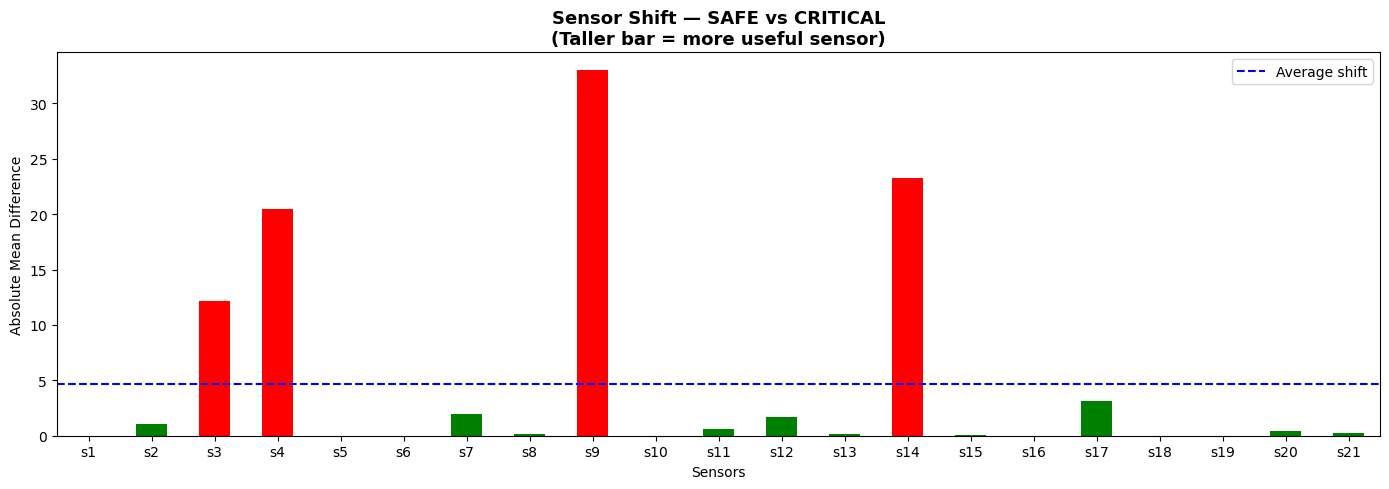

In [15]:
sensors_all = ['s1','s2','s3','s4','s5','s6','s7','s8','s9','s10',
               's11','s12','s13','s14','s15','s16','s17','s18','s19','s20','s21']

safe_means = df[df['condition_label'] == 'SAFE'][sensors_all].mean()
critical_means = df[df['condition_label'] == 'CRITICAL'][sensors_all].mean()
diff = abs(critical_means - safe_means)

plt.figure(figsize=(14, 5))
diff.plot(kind='bar', color=['red' if x > diff.mean() else 'green' for x in diff])
plt.title('Sensor Shift — SAFE vs CRITICAL\n(Taller bar = more useful sensor)',
          fontsize=13, fontweight='bold')
plt.xlabel('Sensors')
plt.ylabel('Absolute Mean Difference')
plt.axhline(y=diff.mean(), color='blue', linestyle='--', label='Average shift')
plt.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 5.3 Feature Selection Decision

Based on **both** std deviation analysis and visual shift analysis, the following sensors are selected:

| Selected Sensors | Reason |
|---|---|
| s2, s3, s4 | High std + clear shift in distribution |
| s7, s9 | Significant shift in SAFE vs CRITICAL |
| s12, s14, s17 | Meaningful std deviation |

Dropped: `s1, s5, s6, s8, s10, s11, s13, s15, s16, s18, s19, s20, s21` — constant or near-zero std  
Dropped: `setting_1, setting_2, setting_3` — FD001 is single operating condition, all constant

In [17]:
drop_columns = ['setting_1', 'setting_2', 'setting_3',
                's1','s5','s6','s8','s10','s13',
                's15','s16','s18','s19',
                's11','s20','s21',
                'condition_label']

df_clean = df.drop(drop_columns, axis=1)
print('Remaining columns:', df_clean.columns.tolist())
print('Shape:', df_clean.shape)

Remaining columns: ['engine_id', 'time_cycle', 's2', 's3', 's4', 's7', 's9', 's12', 's14', 's17', 'rul', 'condition']
Shape: (20631, 12)


## 6. ⚙️ Time Series Feature Engineering

Raw sensor values capture the **current** state of the engine.  
But engine degradation is a **gradual process** — the trend over the last N cycles matters more than any single reading.

For each of the 8 selected sensors, we compute **rolling window features** over the last 10 cycles:

| Feature | What it captures |
|---|---|
| `sensor_mean10` | Gradual degradation trend |
| `sensor_std10` | Sensor instability / fluctuation |
| `sensor_min10` | Lowest reading in the window |
| `sensor_max10` | Peak reading in the window |

**Result:** 8 sensors × 4 features = **32 time series features** → **40 total features**

> 💡 `groupby('engine_id')` ensures rolling calculations don't cross engine boundaries.

In [19]:
sensors = ['s2','s3','s4','s7','s9','s12','s14','s17']
window = 10

for sensor in sensors:
    df_clean[f'{sensor}_mean10'] = df.groupby('engine_id')[sensor]\
        .transform(lambda x: x.rolling(window, min_periods=1).mean())
    df_clean[f'{sensor}_std10'] = df.groupby('engine_id')[sensor]\
        .transform(lambda x: x.rolling(window, min_periods=1).std().fillna(0))
    df_clean[f'{sensor}_min10'] = df.groupby('engine_id')[sensor]\
        .transform(lambda x: x.rolling(window, min_periods=1).min())
    df_clean[f'{sensor}_max10'] = df.groupby('engine_id')[sensor]\
        .transform(lambda x: x.rolling(window, min_periods=1).max())

print('Total features after engineering:', df_clean.shape[1])
df_clean.head()

Total features after engineering: 44


,engine_id,time_cycle,s2,s3,s4,s7,s9,s12,s14,s17,...,s12_min10,s12_max10,s14_mean10,s14_std10,s14_min10,s14_max10,s17_mean10,s17_std10,s17_min10,s17_max10
0,1,1,641.82,1589.70,1400.60,554.36,9046.19,521.66,8138.62,392,...,521.66,521.66,8138.620000,0.000000,8138.62,8138.62,392.000000,0.000000,392.0,392.0
1,1,2,642.15,1591.82,1403.14,553.75,9044.07,522.28,8131.49,392,...,521.66,522.28,8135.055000,5.041671,8131.49,8138.62,392.000000,0.000000,392.0,392.0
2,1,3,642.35,1587.99,1404.20,554.26,9052.94,522.42,8133.23,390,...,521.66,522.42,8134.446667,3.717450,8131.49,8138.62,391.333333,1.154701,390.0,392.0
3,1,4,642.35,1582.79,1401.87,554.45,9049.48,522.86,8133.83,392,...,521.66,522.86,8134.292500,3.050906,8131.49,8138.62,391.500000,1.000000,390.0,392.0
4,1,5,642.37,1582.85,1406.22,554.00,9055.15,522.19,8133.80,393,...,521.66,522.86,8134.194000,2.651326,8131.49,8138.62,391.800000,1.095445,390.0,393.0


## 7. 🔀 Train-Test Split

- `engine_id` and `time_cycle` are identifiers, not predictive features — dropped before modeling.
- `rul` is directly derived from the label — including it would cause **data leakage** — dropped.
- `stratify=y` ensures SAFE/WARNING/CRITICAL ratios are preserved in both train and test sets.

In [21]:
from sklearn.model_selection import train_test_split

df_clean = df_clean.drop(['time_cycle', 'engine_id'], axis=1)

X = df_clean.drop(['condition', 'rul'], axis=1)
y = df_clean['condition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('X_train shape:', X_train.shape)
print('X_test shape: ', X_test.shape)
print('\ny distribution:')
print(y.value_counts())

X_train shape: (16504, 40)
X_test shape:  (4127, 40)

y distribution:
condition
0    15531
1     3500
2     1600
Name: count, dtype: int64


## 8. 🤖 Model Building — Pipeline Comparison

We use **Scikit-learn Pipelines** which chain preprocessing (StandardScaler) and model in one object.  
This prevents **data leakage** — the scaler is fit only on training data and applied to test data.

Four models are compared:
- **Logistic Regression** — simple linear baseline
- **Random Forest** — ensemble of decision trees
- **XGBoost** — gradient boosting, expected winner
- **SVM** — support vector classifier

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

pipelines = {
    'Logistic Regression': Pipeline([('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000, random_state=42))]),
    'Random Forest': Pipeline([('scaler', StandardScaler()),
        ('model', RandomForestClassifier(n_estimators=100, random_state=42))]),
    'XGBoost': Pipeline([('scaler', StandardScaler()),
        ('model', XGBClassifier(random_state=42, eval_metric='mlogloss'))]),
    'SVM': Pipeline([('scaler', StandardScaler()),
        ('model', SVC(random_state=42))])
}

results = {}
for name, pipeline in pipelines.items():
    print(f'Training {name}...')
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f'✅ {name}: {acc*100:.2f}%')
    print('-'*40)

print(f'\n🏆 Best Model: {max(results, key=results.get)}')
print(f'🎯 Best Accuracy: {max(results.values())*100:.2f}%')

Training Logistic Regression...
✅ Logistic Regression: 90.96%
----------------------------------------
Training Random Forest...
✅ Random Forest: 97.09%
----------------------------------------
Training XGBoost...
✅ XGBoost: 98.23%
----------------------------------------
Training SVM...
✅ SVM: 92.56%
----------------------------------------

🏆 Best Model: XGBoost
🎯 Best Accuracy: 98.23%


## 9. 📈 Model Evaluation

### 9.1 Classification Report & Confusion Matrix

The **Confusion Matrix** shows exactly where the model makes mistakes.  
Most critical metric: **CRITICAL misclassified as SAFE** — in a safety-critical system, this is the most dangerous error.  
> ✅ Goal: Zero CRITICAL engines predicted as SAFE.

📊 Classification Report:
              precision    recall  f1-score   support

        SAFE       0.99      1.00      0.99      3107
     WARNING       0.96      0.94      0.95       700
    CRITICAL       0.96      0.94      0.95       320

    accuracy                           0.98      4127
   macro avg       0.97      0.96      0.96      4127
weighted avg       0.98      0.98      0.98      4127



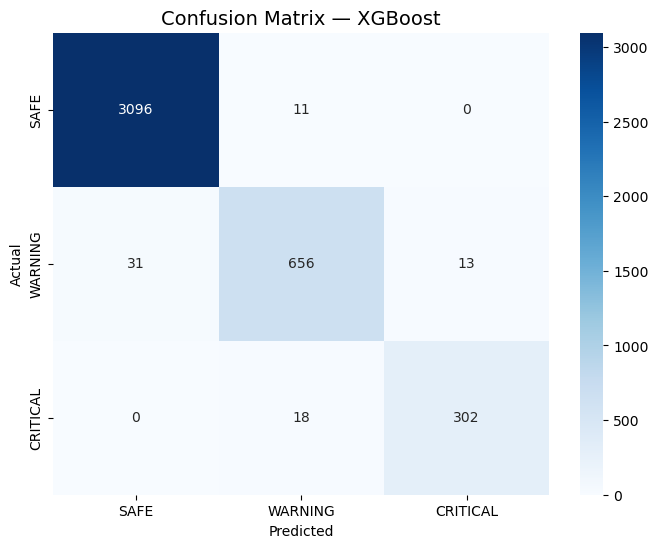

In [25]:
from sklearn.metrics import classification_report, confusion_matrix

best_pipeline = pipelines['XGBoost']
y_pred = best_pipeline.predict(X_test)

print('📊 Classification Report:')
print(classification_report(y_test, y_pred,
      target_names=['SAFE', 'WARNING', 'CRITICAL']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['SAFE', 'WARNING', 'CRITICAL'],
            yticklabels=['SAFE', 'WARNING', 'CRITICAL'])
plt.title('Confusion Matrix — XGBoost', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### 9.2 Cross-Validation

A single train-test split can be lucky or unlucky depending on how the data is split.  
**5-Fold Cross-Validation** trains and tests the model 5 times on different splits — the average is more trustworthy.

> Low standard deviation (< 1%) indicates the model is **consistent** across different data splits.

In [27]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(best_pipeline, X, y, cv=5, scoring='accuracy')

print('Fold-wise Accuracy:')
for i, s in enumerate(scores):
    print(f'  Fold {i+1}: {s*100:.2f}%')
print(f'\n🏆 Average Accuracy: {scores.mean()*100:.2f}%')
print(f'📈 Std Deviation:    {scores.std()*100:.2f}%')

Fold-wise Accuracy:
  Fold 1: 91.13%
  Fold 2: 89.84%
  Fold 3: 89.89%
  Fold 4: 88.95%
  Fold 5: 89.21%

🏆 Average Accuracy: 89.81%
📈 Std Deviation:    0.76%


## 10. 🔑 Feature Importance

XGBoost assigns an importance score to each feature based on how frequently it is used in tree splits.  

**Key Insight:** The top features are all `_mean10` variants — confirming that the **rolling mean** (10-cycle trend) is the most predictive signal.  
This validates our time series feature engineering approach — raw sensor values alone would have been less powerful.

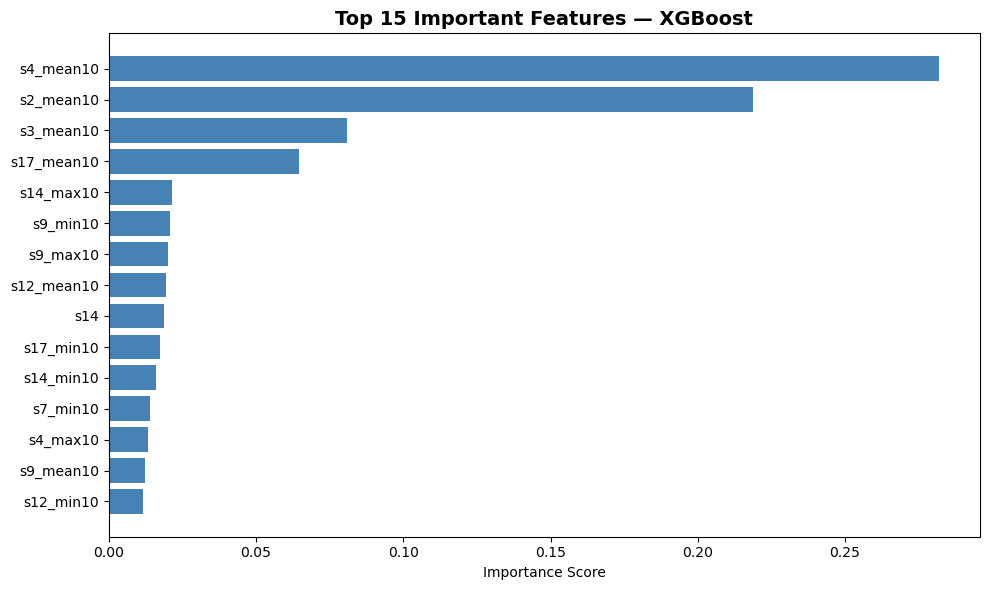

       Feature  Importance
16   s4_mean10    0.281725
8    s2_mean10    0.218892
12   s3_mean10    0.081061
36  s17_mean10    0.064535
35   s14_max10    0.021535
26    s9_min10    0.020667
27    s9_max10    0.019966
28  s12_mean10    0.019334
6          s14    0.018763
38   s17_min10    0.017313
34   s14_min10    0.016062
22    s7_min10    0.013961
19    s4_max10    0.013468
24   s9_mean10    0.012266
30   s12_min10    0.011519


In [29]:
xgb_model = pipelines['XGBoost'].named_steps['model']
importance = xgb_model.feature_importances_

feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(feat_imp['Feature'], feat_imp['Importance'], color='steelblue')
plt.title('Top 15 Important Features — XGBoost', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(feat_imp)

## 11. 💾 Save Model & Data

The trained XGBoost pipeline and feature column names are saved as pickle files for use in the Streamlit dashboard.

In [31]:
import pickle

# Save model
with open('bioguard_model.pkl', 'wb') as f:
    pickle.dump(pipelines['XGBoost'], f)

# Save feature columns
with open('feature_cols.pkl', 'wb') as f:
    pickle.dump(list(X.columns), f)

# Save processed data for dashboard
df_clean['engine_id'] = df['engine_id']
df_clean['time_cycle'] = df['time_cycle']
df_clean.to_csv('df_clean.csv', index=False)

print('✅ bioguard_model.pkl saved')
print('✅ feature_cols.pkl saved')
print('✅ df_clean.csv saved')

✅ bioguard_model.pkl saved
✅ feature_cols.pkl saved
✅ df_clean.csv saved


## 12. 📋 Project Summary

| Metric | Value |
|---|---|
| Dataset | NASA CMAPSS FD001 |
| Total Engines | 100 |
| Total Readings | 20,631 |
| Sensors Used | 8 (selected from 21) |
| Total Features | 40 (8 raw + 32 time series) |
| Best Model | XGBoost |
| Test Accuracy | 98% |
| Cross-Validated Accuracy | 89.81% ± 0.76% |
| CRITICAL → SAFE Misclassification | 0 ✅ |

---

### 🔮 Real World Application

This is a **proof of concept** built on historical NASA data.  
In a real deployment:
- Live IoT sensor streams replace the CSV
- The same trained model predicts on each incoming cycle in real time
- Engineers receive alerts before engine failure occurs

**Direct applications:** Commercial Aviation MRO | Defence (DRDO) | Industrial IoT | Power Plants

---
**🔗 Live Demo:** [BioGuard Streamlit App](🚀 Built BioGuard — An AI-Powered Aircraft Engine Health Monitoring System!

Traditional maintenance is either reactive (fix after failure) or scheduled (fixed intervals). Both are inefficient. BioGuard enables Condition-Based Predictive Maintenance — predict failure BEFORE it happens.

⚙️ What I Built:
→ Processed NASA CMAPSS dataset — 100 engines, 20,631 sensor readings
→ Engineered Time Series features using rolling window analysis (mean, std, min, max) capturing gradual degradation patterns invisible to standard ML
→ Selected 8 key sensors using std deviation + visual shift analysis
→ Compared 4 ML models using Scikit-learn Pipelines — XGBoost won
→ 0 CRITICAL engines misclassified as SAFE ✅ — most critical metric in safety systems
→ Live real-time simulation — watch engine degrade cycle by cycle!

📊 Results:
✅ 89.81% Cross-Validated Accuracy (±0.76%)
✅ 98% Test Accuracy
✅ 0 Critical Misclassifications

🛠️ Python | XGBoost | Scikit-learn | Time Series | Streamlit

🔗 Live Demo: [streamlit link]
🔗 GitHub: [github link]

Direct applications in Aviation MRO, Defence, Industrial IoT & Manufacturing.

2nd year B.Tech — Automation & Robotics 🚀

#DataScience #MachineLearning #PredictiveMaintenance #TimeSeries #Python #NASA #DRDO)  
**👨‍💻 Author:** Yash Dhollakhandi | B.Tech Automation & Robotics | Delhi